#### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import math
import warnings
warnings.filterwarnings('ignore')

#### Features Names

In [2]:
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['Fan_Inlet_Temperature', 'LPC_Outlet_Temperature', 'HPC_Outlet_Temperature', 'LPT Outlet Temperature', 'Fan Inlet Pressure', 'Bypass-Duct Pressure', 
                'HPC Outlet Pressure', 'Physical Fan Speed', 'Physical Core Speed', 'Engine Pressure Ratio(P50/P2)', 'HPC Outlet Static Pressure',
                'Ratio of Fuel Flow to Ps30', 'Corrected Fan Speed', 'Corrected Core Speed', 'Bypass Ratio', 
                'Burner Fuel-Air Ratio', 'Bleed Enthalpy', 'Required Fan Speed', 'Required Fan Conversion Speed', 'High-Pressure Turbines Cool Air Flow', 'Low-Pressure Turbines Cool Air Flow']

column_names = index_names + setting_names + sensor_names

#### Import Datasets

In [3]:
file_path1 = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/Turbofan_Jet_Engine/CMaps/train_FD001.txt" 
Set1_Train =  pd.read_csv(file_path1, delimiter=' ', header = None, index_col = False, names = column_names)
#display(Set1_Train)

file_path2 = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/Turbofan_Jet_Engine/CMaps/test_FD001.txt" 
Set1_X_Test =  pd.read_csv(file_path2, delimiter=' ', header = None, index_col = False, names = column_names)
#display(Set1_Test)

file_path3 = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/Turbofan_Jet_Engine/CMaps/RUL_FD001.txt" 
Set1_y_Test =  pd.read_csv(file_path3, delimiter=' ', header = None, index_col = False, names= ['RUL'])
#display(Set1_y_Test)

#### Dataset Inspection

In [4]:
print('Shape of the train dataset : ', Set1_Train.shape)
print('Shape of the validation dataset : ', Set1_X_Test.shape)

missing_values = Set1_Train.isna().sum()
print("Columns with missing values:\n", missing_values)

Shape of the train dataset :  (20631, 26)
Shape of the validation dataset :  (13096, 26)
Columns with missing values:
 unit_number                             0
time_cycles                             0
setting_1                               0
setting_2                               0
setting_3                               0
Fan_Inlet_Temperature                   0
LPC_Outlet_Temperature                  0
HPC_Outlet_Temperature                  0
LPT Outlet Temperature                  0
Fan Inlet Pressure                      0
Bypass-Duct Pressure                    0
HPC Outlet Pressure                     0
Physical Fan Speed                      0
Physical Core Speed                     0
Engine Pressure Ratio(P50/P2)           0
HPC Outlet Static Pressure              0
Ratio of Fuel Flow to Ps30              0
Corrected Fan Speed                     0
Corrected Core Speed                    0
Bypass Ratio                            0
Burner Fuel-Air Ratio                   0

#### Unit Lifetime

0        192
1        192
2        192
3        192
4        192
        ... 
20626    200
20627    200
20628    200
20629    200
20630    200
Name: time_cycles, Length: 20631, dtype: int64


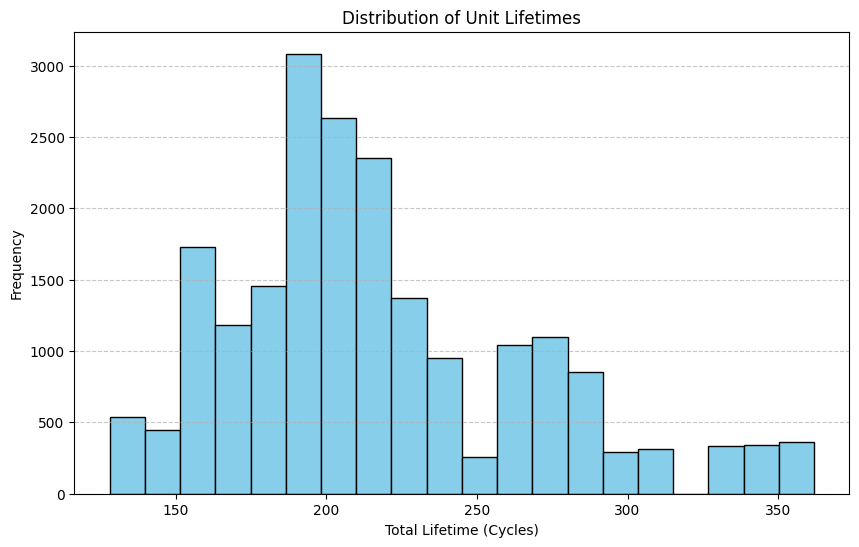

In [5]:
unit_lifetime = Set1_Train.groupby('unit_number')['time_cycles'].transform('max')
print(unit_lifetime)

plt.figure(figsize=(10, 6))
plt.hist(unit_lifetime, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Unit Lifetimes')
plt.xlabel('Total Lifetime (Cycles)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### RUL Column

In [6]:
Set1_Train['RUL'] = unit_lifetime - Set1_Train['time_cycles']

unit_rul_df = Set1_Train[['unit_number', 'RUL']]
display(unit_rul_df)

,unit_number,RUL
0,1,191
1,1,190
2,1,189
3,1,188
4,1,187
...,...,...
20626,100,4
20627,100,3
20628,100,2
20629,100,1


#### Attributes Correlations

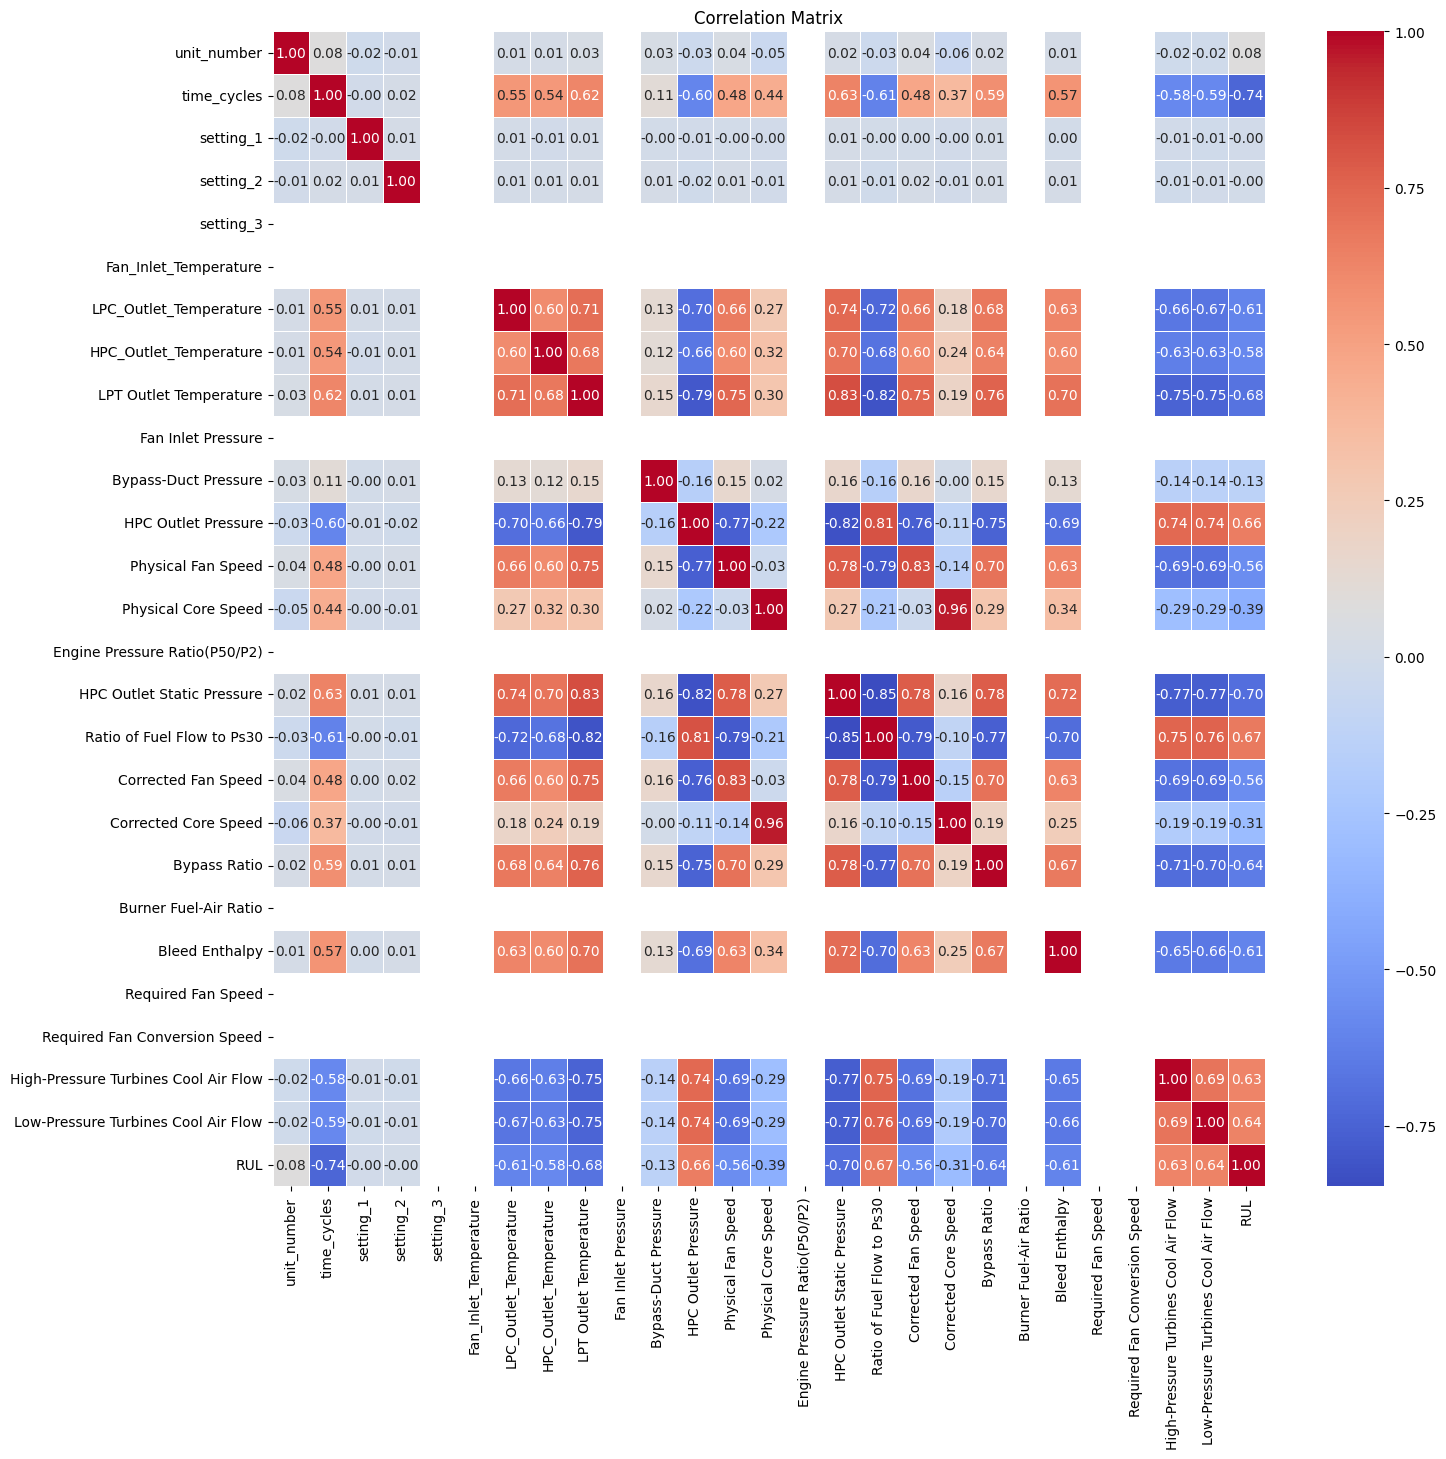

In [7]:
correlation_matrix = Set1_Train.corr()
plt.figure(figsize=(16, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

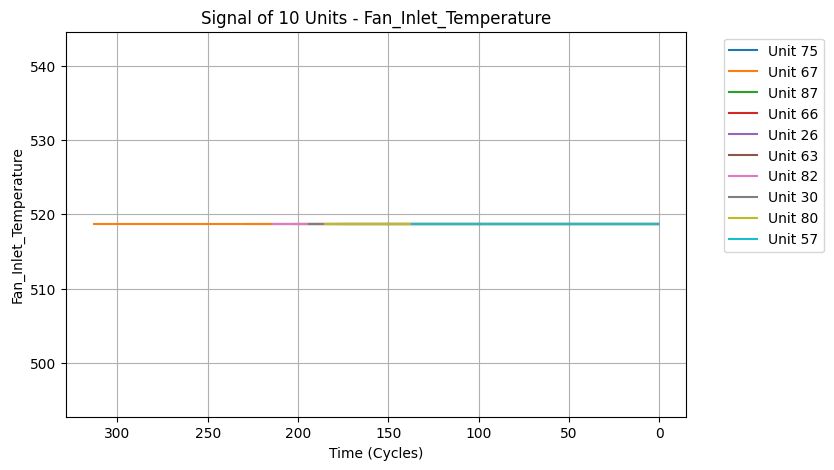

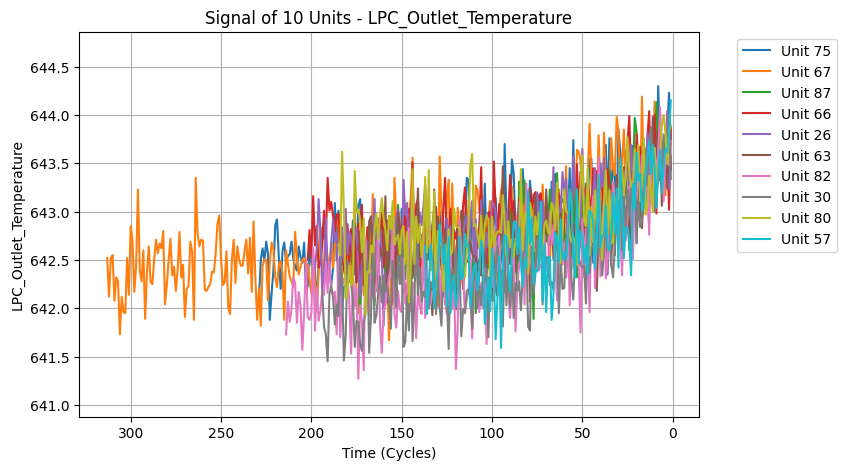

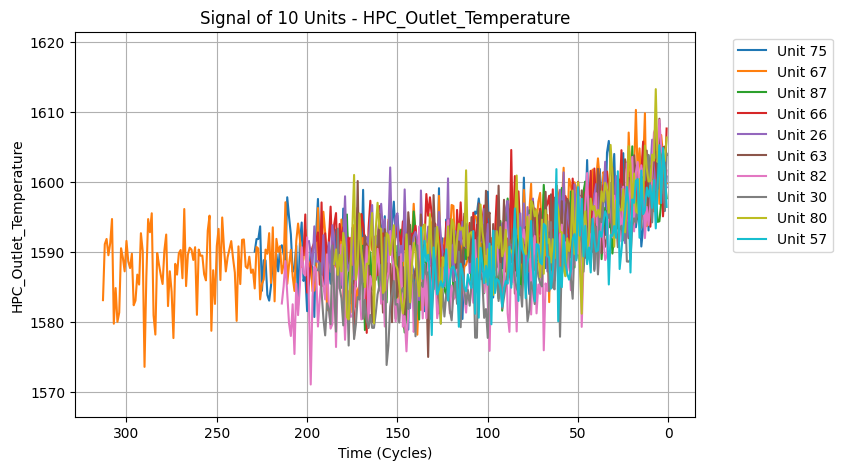

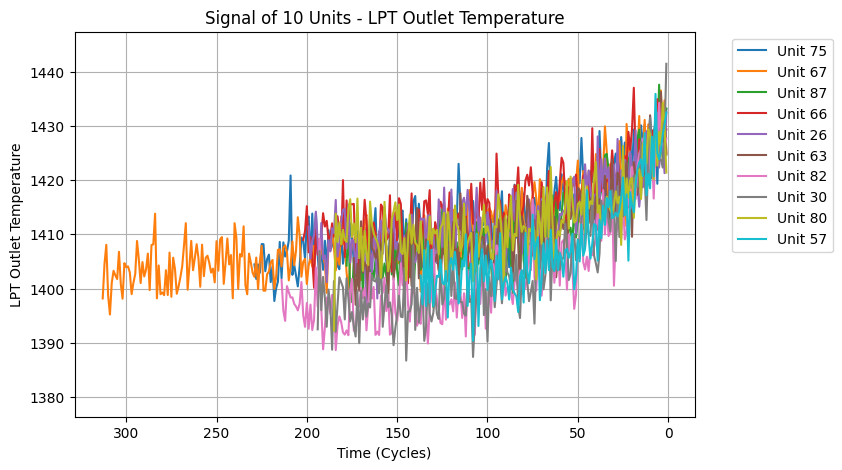

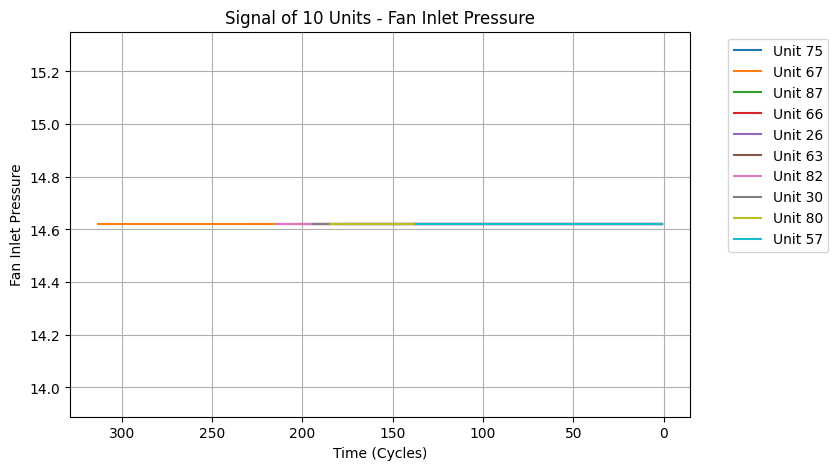

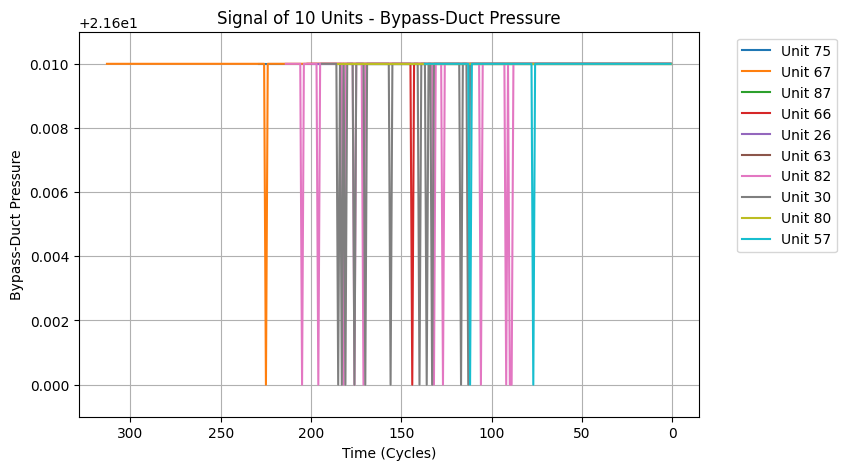

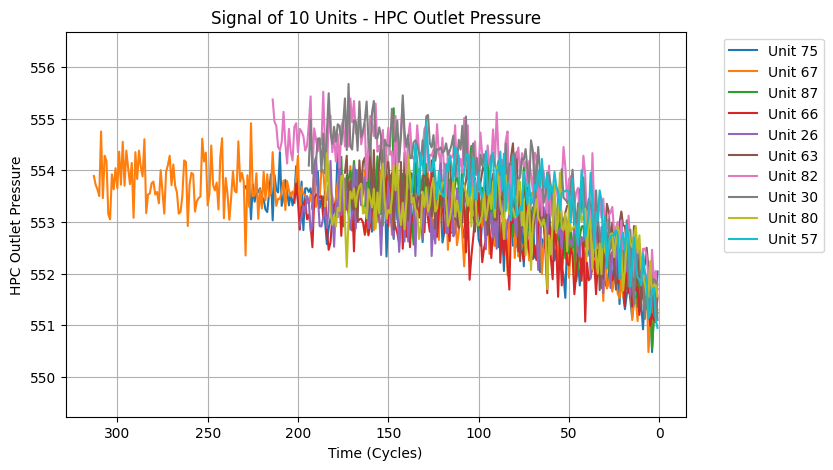

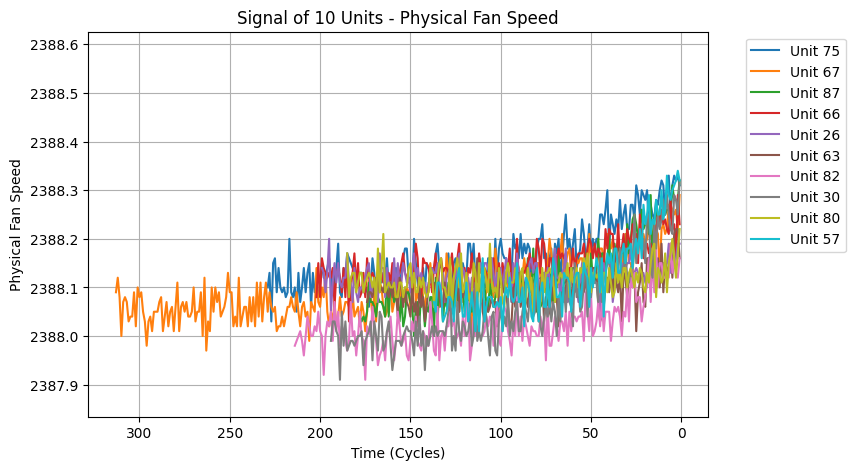

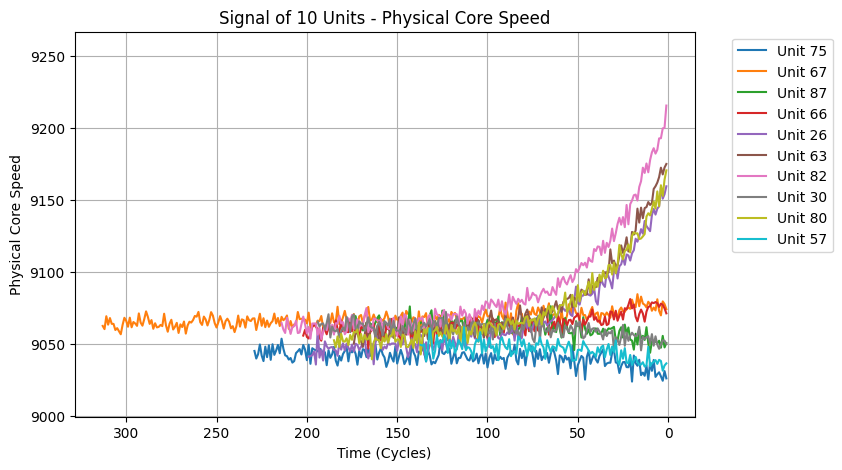

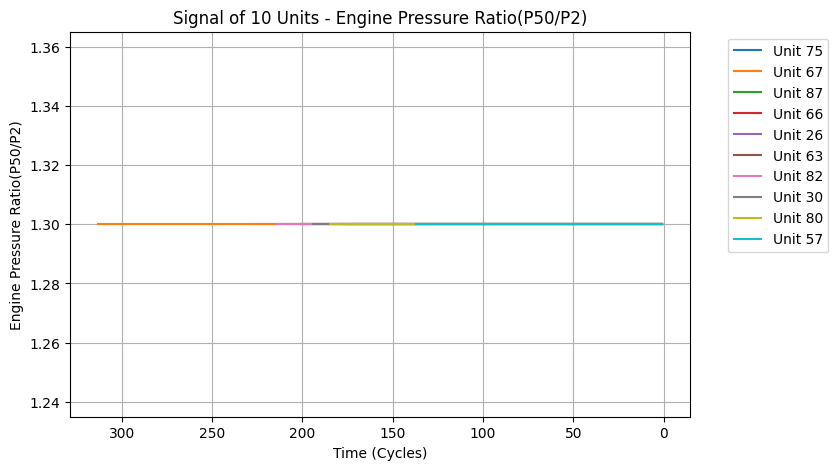

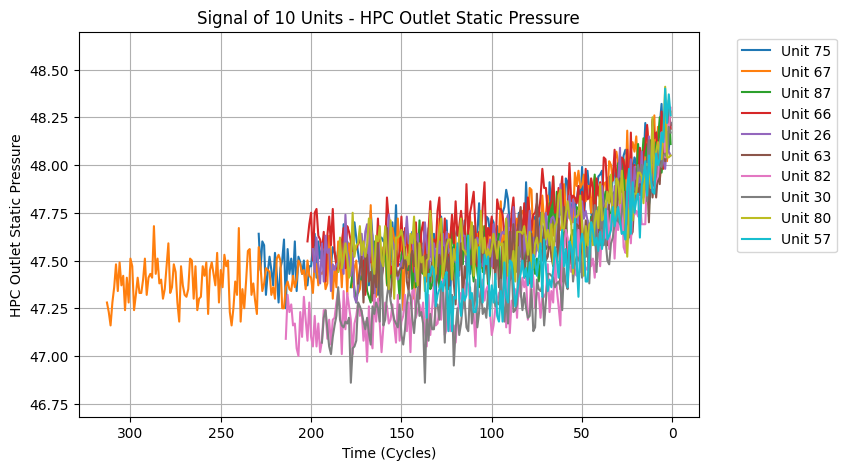

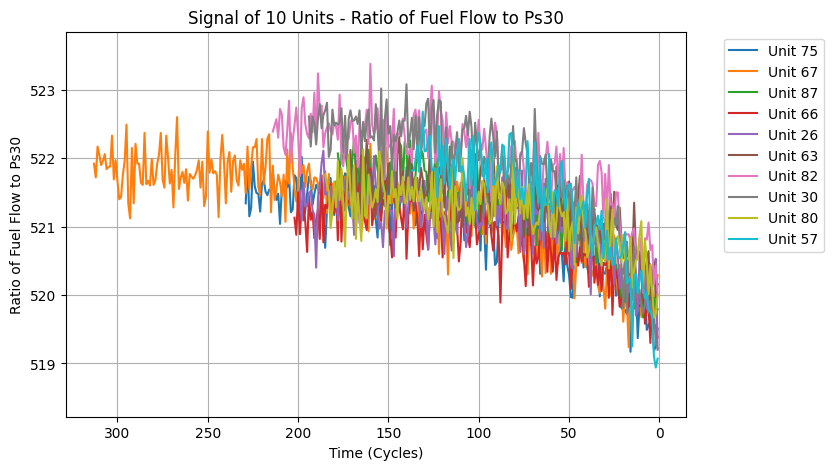

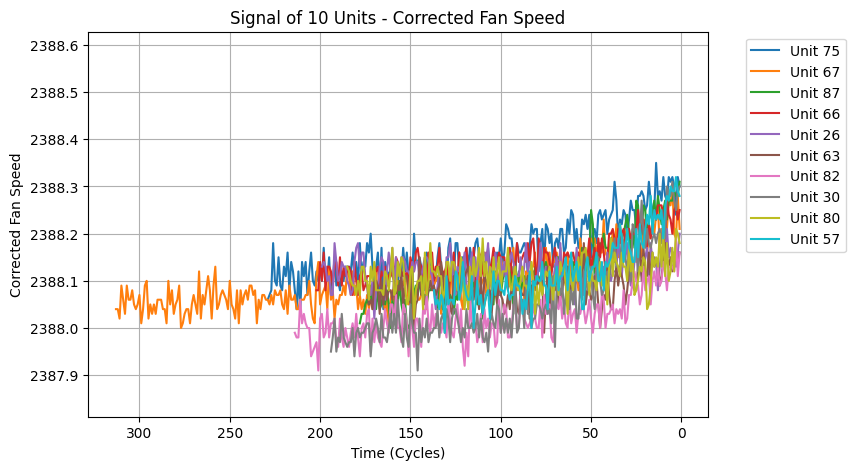

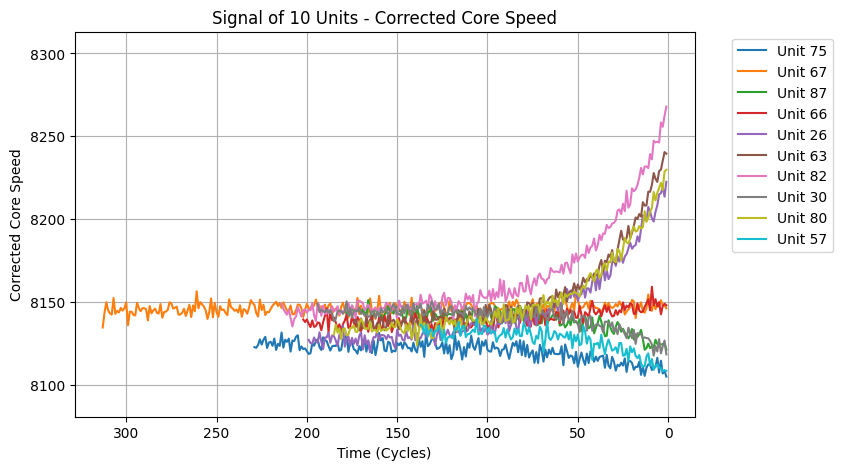

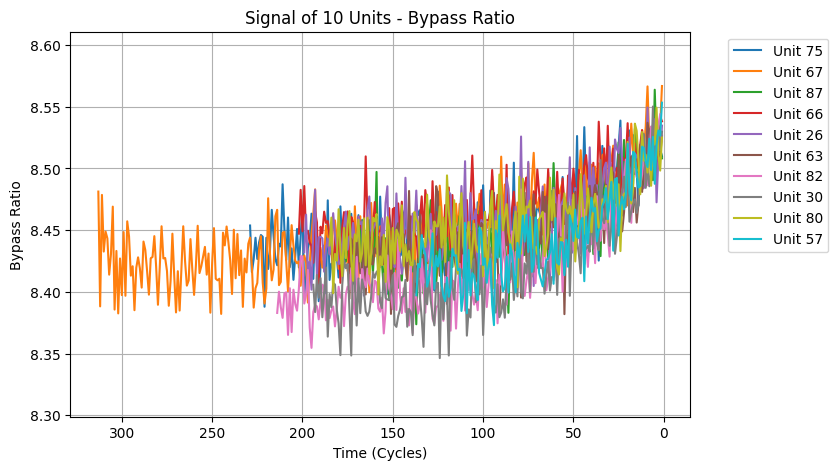

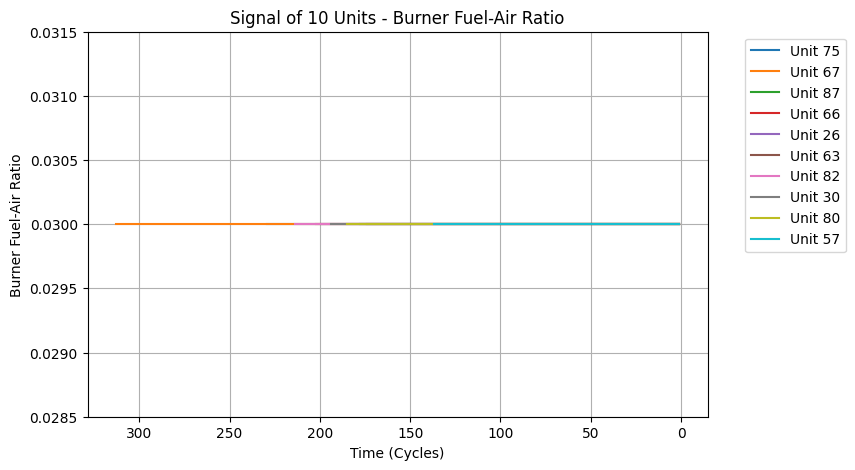

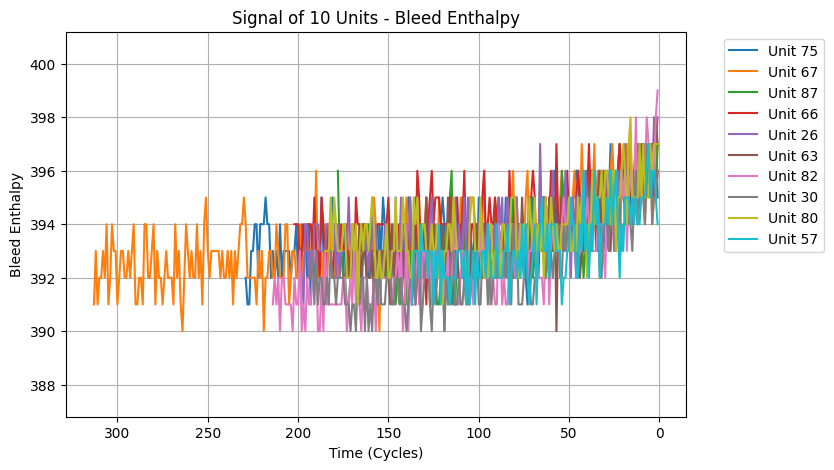

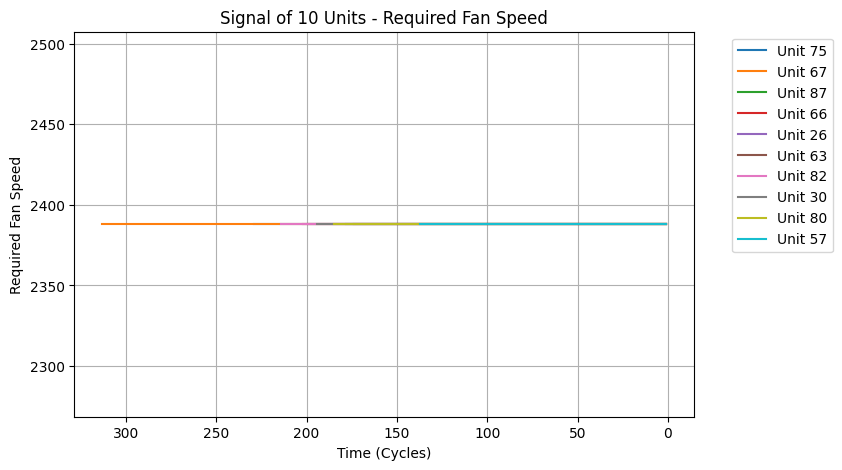

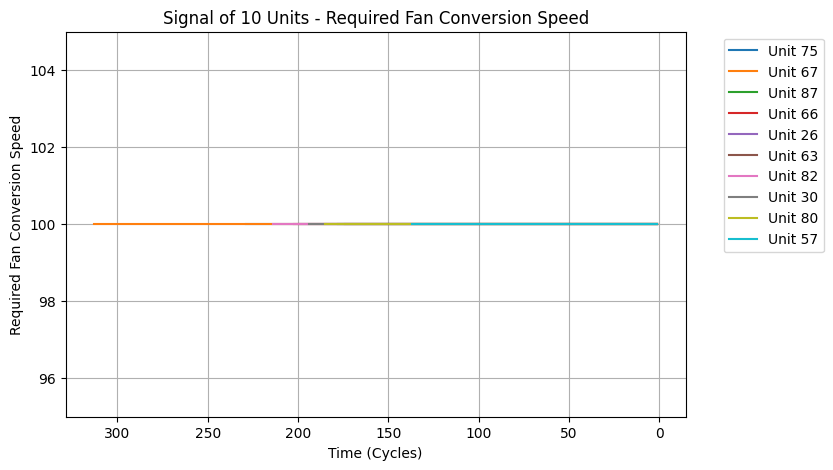

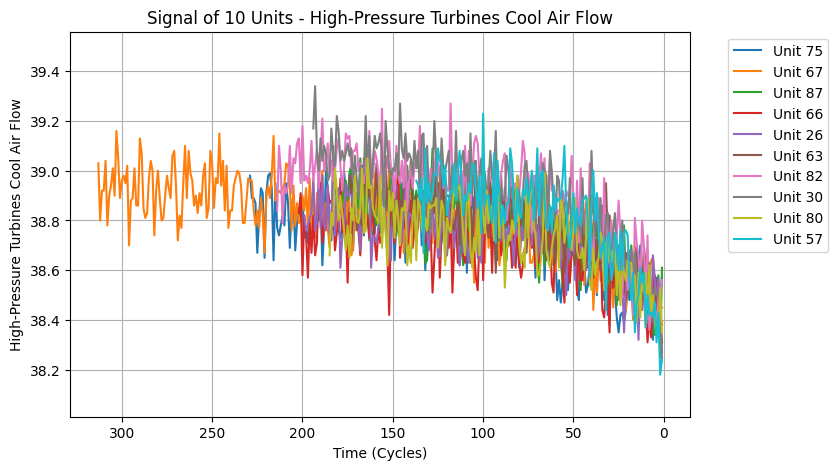

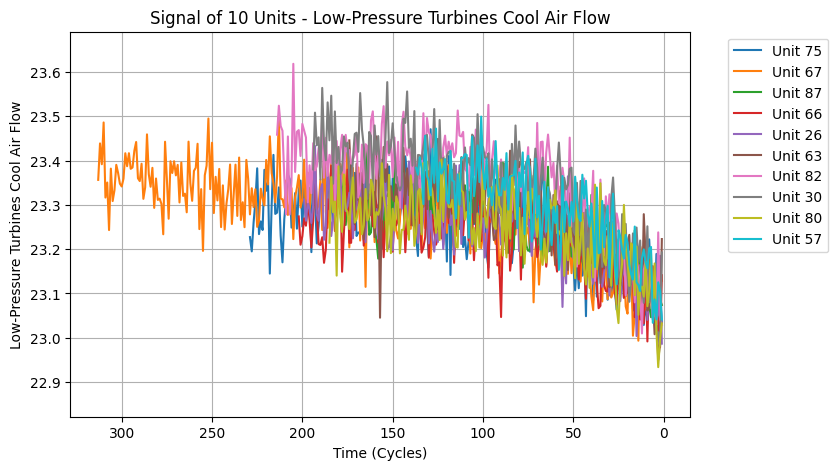

In [8]:
rul_column = 'RUL' 

num_units = 10

selected_unit_numbers = np.random.choice(Set1_Train['unit_number'].unique(), num_units, replace=False)

for sensor in sensor_names:
    plt.figure(figsize=(8, 5))
    for i, unit_number in enumerate(selected_unit_numbers):
        color = plt.cm.tab10(i)  
        plt.plot(Set1_Train[Set1_Train['unit_number'] == unit_number]['time_cycles'][::-1],
                 Set1_Train[Set1_Train['unit_number'] == unit_number][sensor],
                 label=f'Unit {unit_number}', color=color)

    min_value = Set1_Train[sensor].min()
    max_value = Set1_Train[sensor].max()
    y_range = max_value - min_value
    plt.ylim(min_value - 0.1 * y_range, max_value + 0.1 * y_range)

    plt.title(f'Signal of 10 Units - {sensor}')
    plt.xlabel('Time (Cycles)')
    plt.ylabel(sensor)
    plt.gca().invert_xaxis() 
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.show()

#### Find Outliers

In [9]:
Set1_Train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
Fan_Inlet_Temperature,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
LPC_Outlet_Temperature,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
HPC_Outlet_Temperature,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
LPT Outlet Temperature,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
Fan Inlet Pressure,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


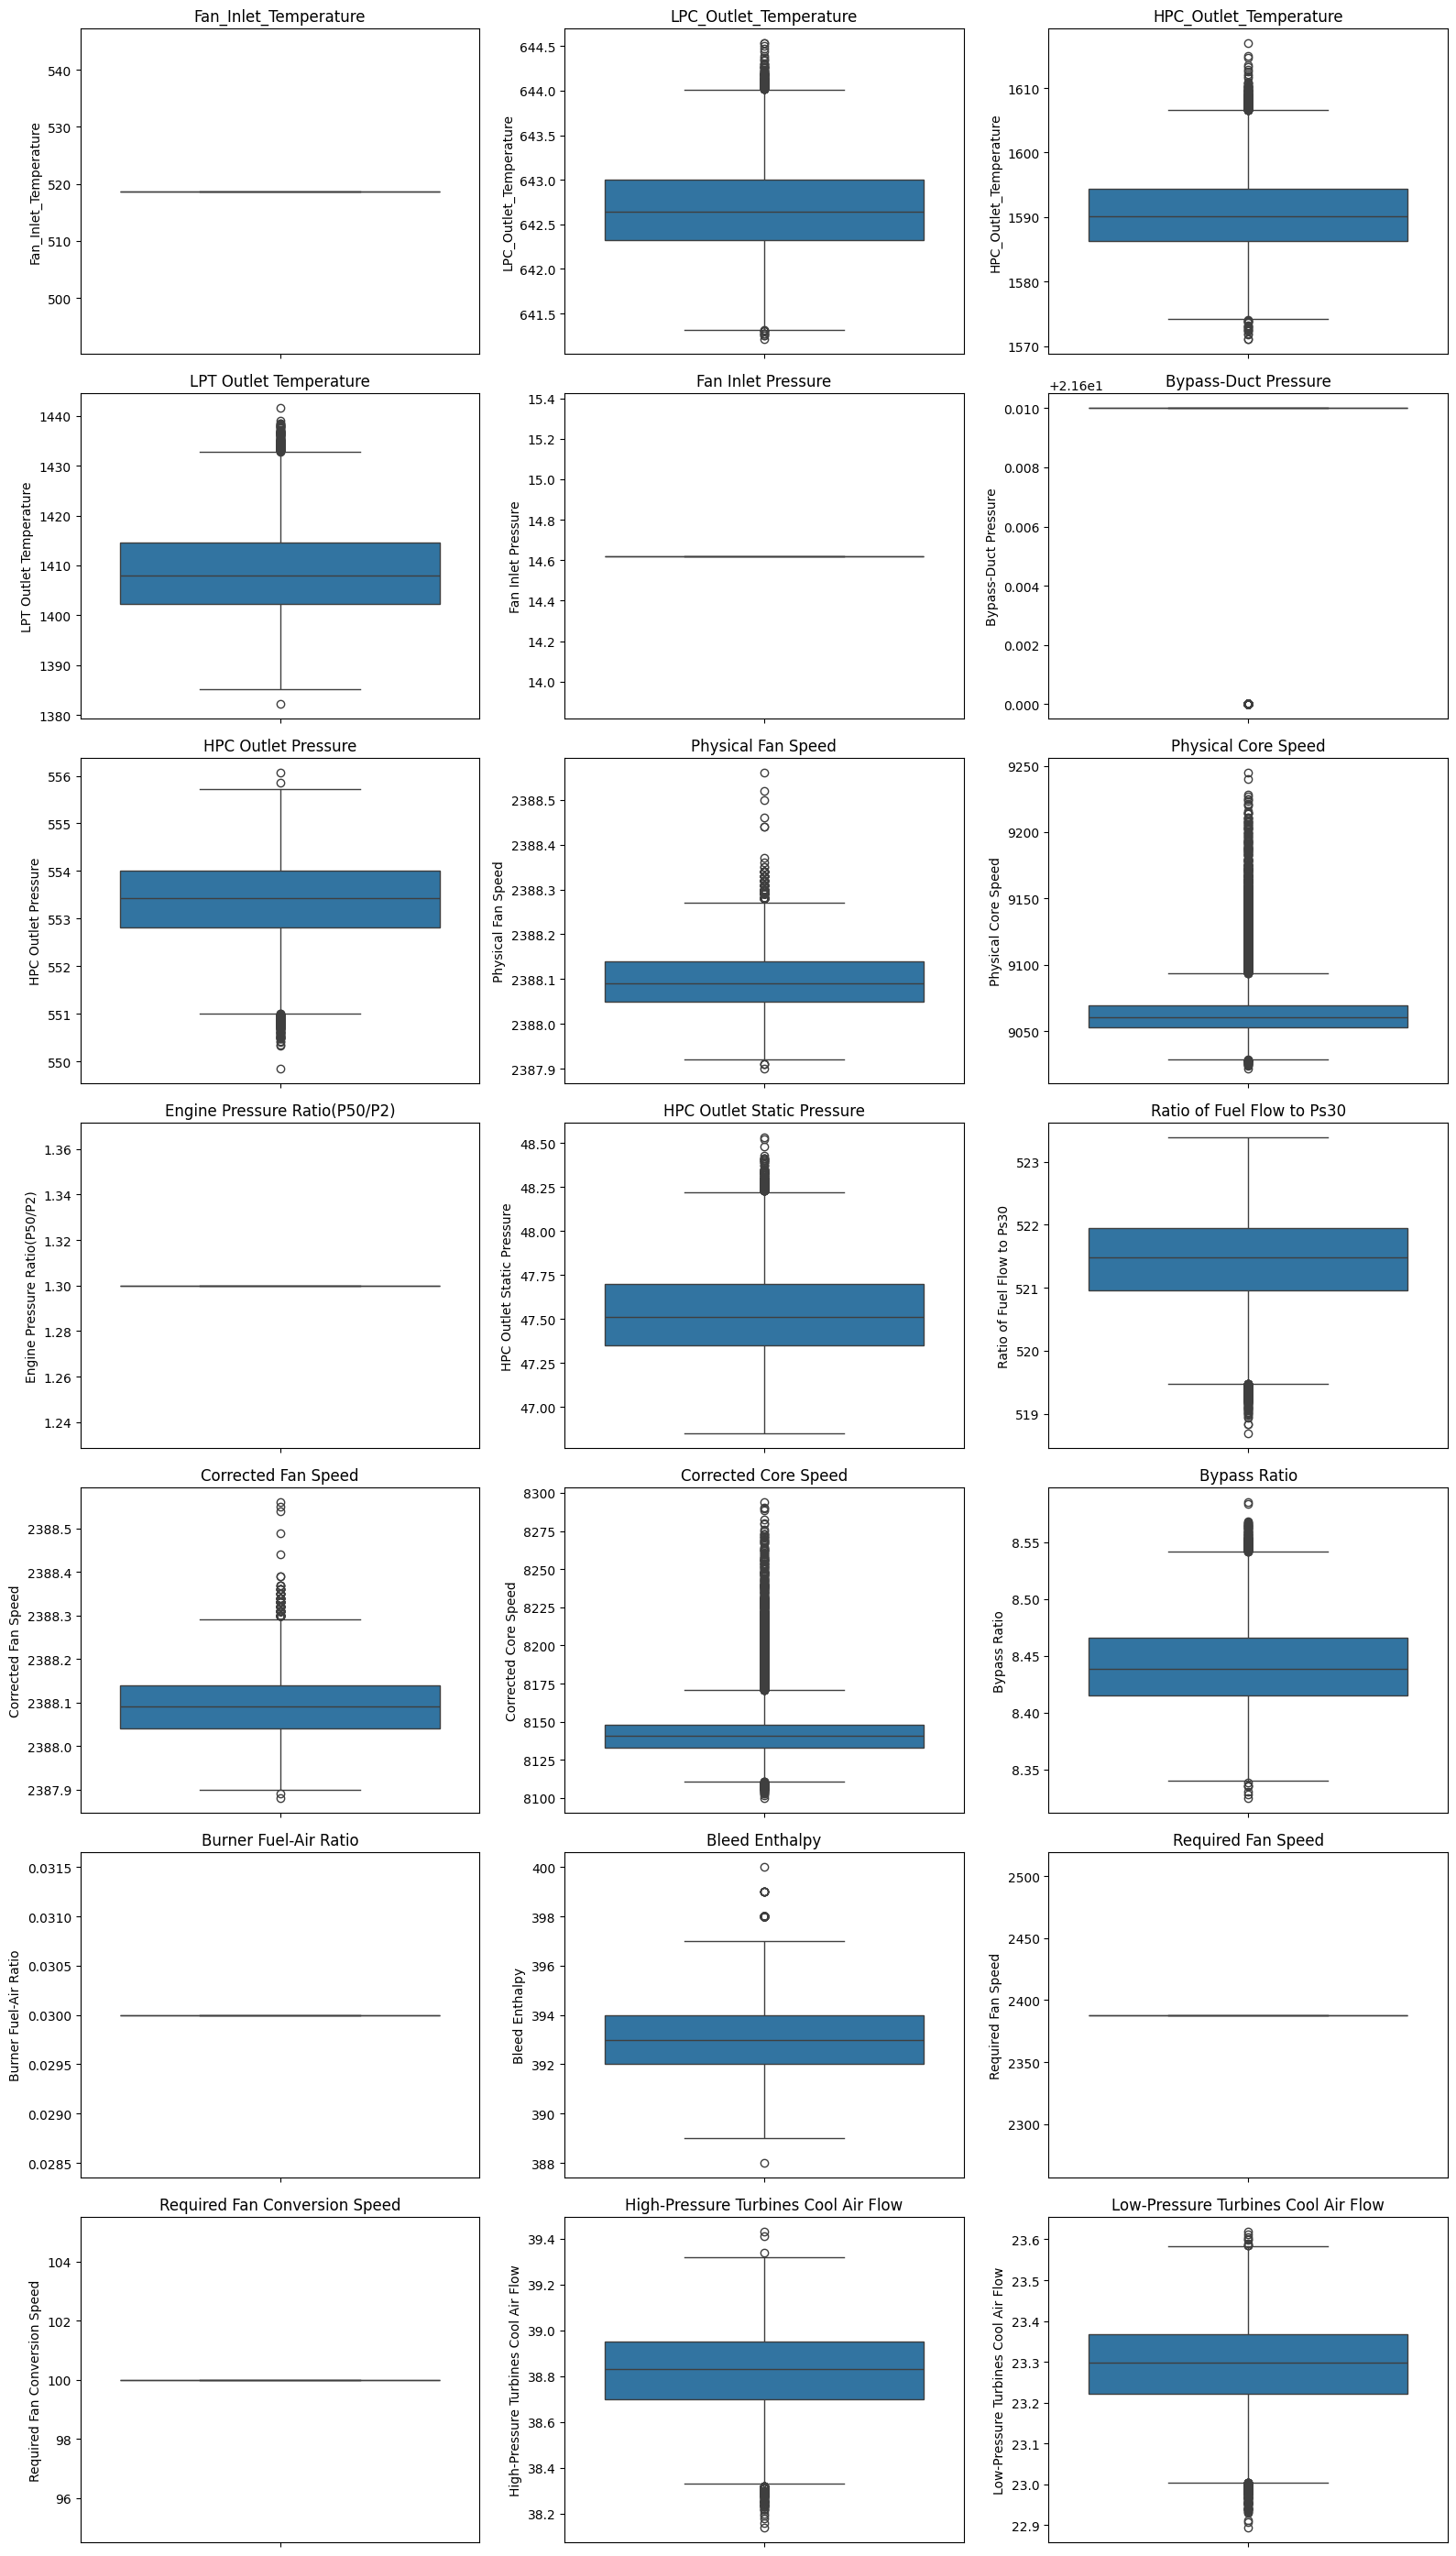

In [10]:
num_plots = len(sensor_names)
num_cols = 3
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 4*num_rows))  

for i, ax in enumerate(axes.flat):
    if i < num_plots:
        sns.boxplot(Set1_Train[sensor_names[i]], ax=ax)
        ax.set_title(sensor_names[i])

plt.tight_layout()
plt.show()

#### MinMax Scaling

In [11]:
Set1_X_Train = Set1_Train.drop(columns = index_names + setting_names + ['RUL'])
Set1_y_Train = Set1_Train['RUL']

Set1_X_Test = Set1_X_Test.drop(columns = index_names + setting_names)